In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Unzip file

In [ ]:
!unzip /content/drive/MyDrive/Project_Dataset/archive.zip
!unzip /content/drive/MyDrive/Project_Dataset/Best_models.zip

Streaming output truncated to the last 5000 lines.
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/2e164016-5845-40c3-919b-6953bf72a67a___RS_HL 1877_new30degFlipLR.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/2ec57765-dacf-4ed3-b753-eff3fe27a3d1___RS_HL 4763_180deg.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/2ec57765-dacf-4ed3-b753-eff3fe27a3d1___RS_HL 4763_new30degFlipLR.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/2fbe071f-efd0-4a93-97b5-38160dafa0c5___RS_HL 2146.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/2fbe071f-efd0-4a93-97b5-38160dafa0c5___RS_HL 2146_270deg.JPG  
  inflating: new plant diseases dataset(augme

#VGG19

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import VGG19, preprocess_input

In [ ]:
# Data Analysis
#Calculating the classes
len(os.listdir('/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'))

38

In [ ]:
#Data generate
train_datagen = ImageDataGenerator(zoom_range= 0.5, shear_range= 0.3,
                                   horizontal_flip= True,
                                   preprocessing_function= preprocess_input)

val_datagen = ImageDataGenerator(preprocessing_function= preprocess_input)

In [ ]:
train = train_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
                                          target_size=(224,224),
                                          batch_size=64)
val = val_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
                                          target_size=(224,224),
                                          batch_size=64)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [ ]:
t_img, label = next(train)

In [ ]:
t_img.shape

(64, 224, 224, 3)

In [ ]:
classes=list(train.class_indices)
print(len(classes),'\n',classes)

38 
 ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Targ

In [ ]:
def plotImage(img_arr,label):
  for im, l in zip(img_arr,label):
    plt.imshow(im)
    plt.figure(figsize= (5,5))
    plt.show()

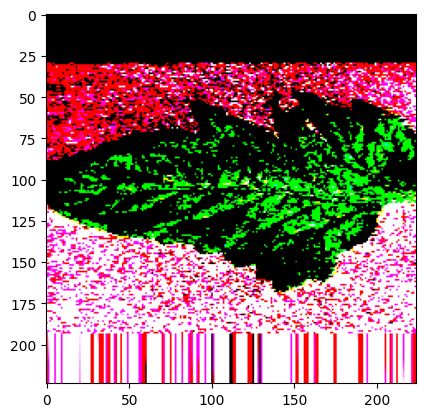

<Figure size 500x500 with 0 Axes>

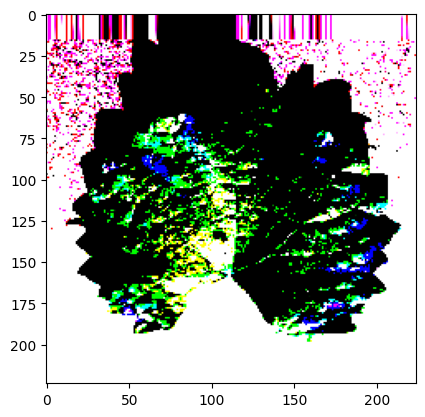

<Figure size 500x500 with 0 Axes>

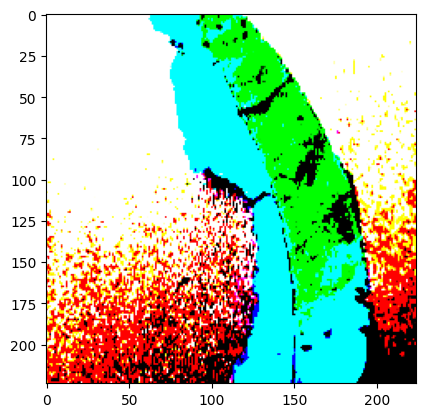

<Figure size 500x500 with 0 Axes>

In [ ]:
plotImage(t_img[:3], label[:3])

In [ ]:
diseases = os.listdir(train_dir)
print(diseases)

['Tomato___Early_blight', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Pepper,_bell___healthy', 'Corn_(maize)___Common_rust_', 'Raspberry___healthy', 'Strawberry___healthy', 'Grape___healthy', 'Tomato___Septoria_leaf_spot', 'Tomato___Tomato_mosaic_virus', 'Orange___Haunglongbing_(Citrus_greening)', 'Blueberry___healthy', 'Grape___Black_rot', 'Cherry_(including_sour)___Powdery_mildew', 'Apple___healthy', 'Peach___Bacterial_spot', 'Apple___Apple_scab', 'Tomato___Late_blight', 'Tomato___Bacterial_spot', 'Potato___Late_blight', 'Corn_(maize)___healthy', 'Potato___healthy', 'Peach___healthy', 'Strawberry___Leaf_scorch', 'Squash___Powdery_mildew', 'Grape___Esca_(Black_Measles)', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Apple___Cedar_apple_rust', 'Pepper,_bell___Bacterial_spot', 'Tomato___healthy', 'Cherry_(including_sour)___healthy', 'Soybean___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Target_Spot', 'Apple___Black_rot', 'Tomato___Leaf_Mold', 'Grape___Leaf_blight_(Isar

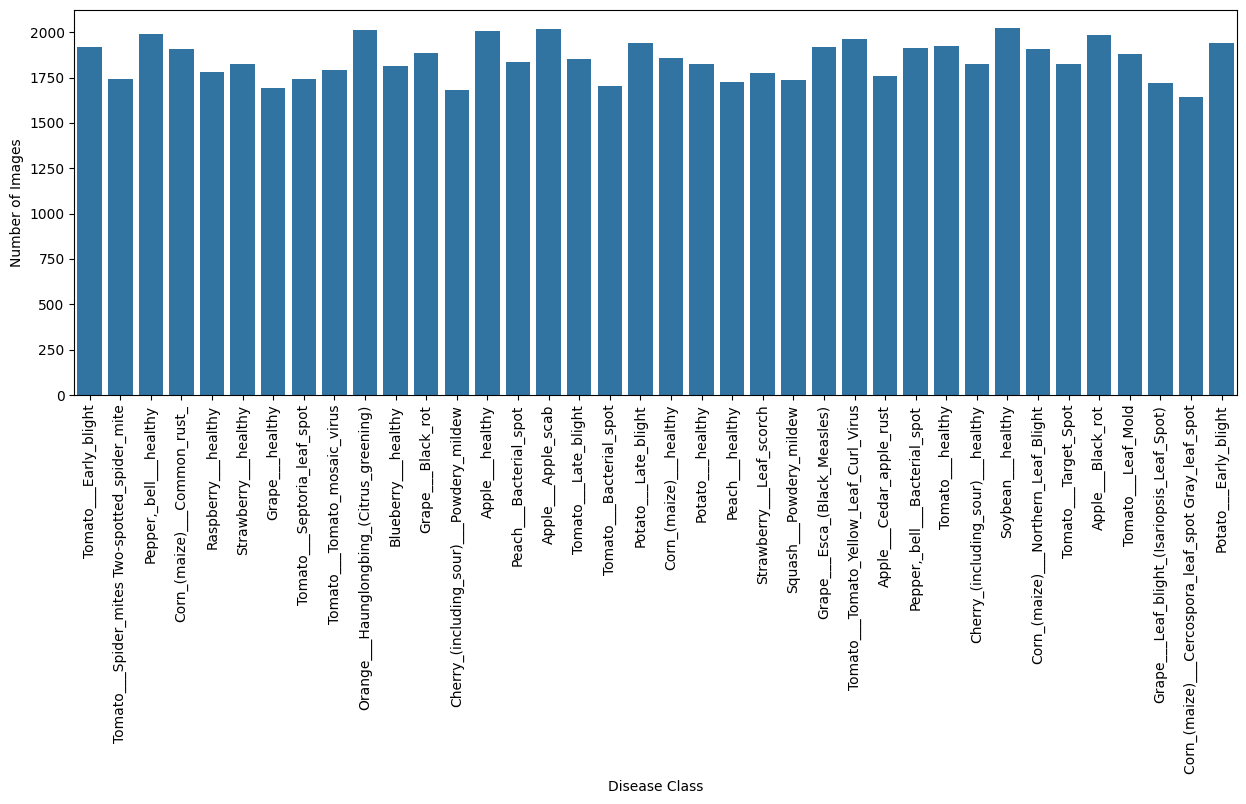

In [ ]:
import seaborn as sns
dic = {}
for Class in diseases:
    dic[Class] = len(os.listdir(train_dir + '/' + Class))

df = pd.DataFrame(list(dic.items()), columns=["Disease Class", "Number of Images"])

# df = df.sort_values(by="Number of Images", ascending=False)

plt.figure(figsize=(15,5))
sns.barplot(data=df ,x='Disease Class' ,y= 'Number of Images' )
plt.xticks(rotation=90)
plt.show()

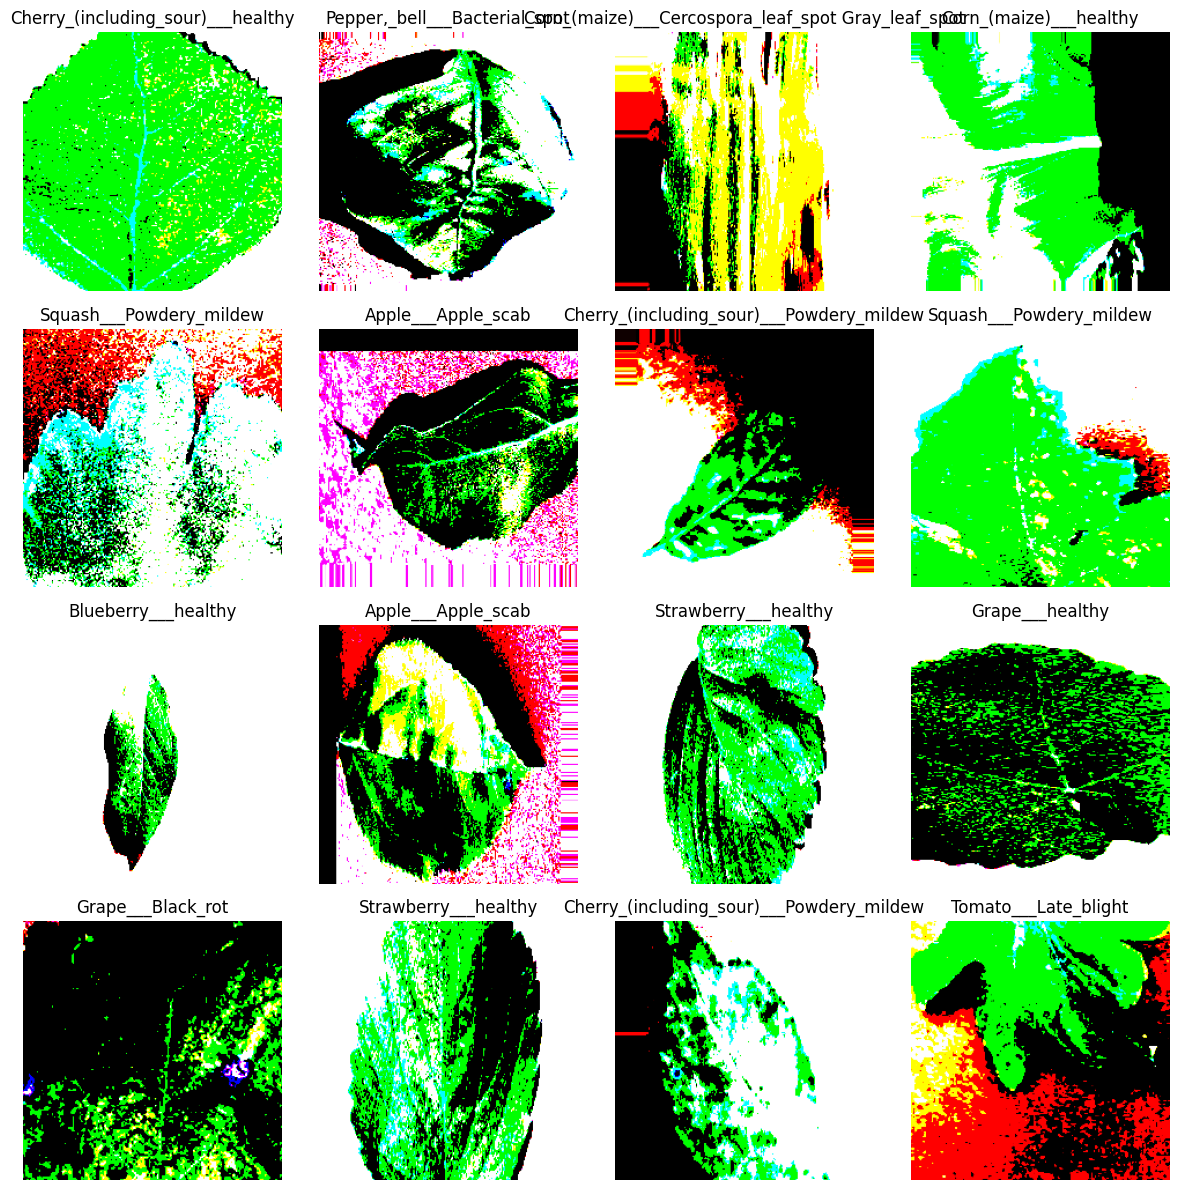

In [ ]:
import random
# select a specific batch
images, labels = next(iter(train))

# select 16 image by random
indices = random.sample(range(len(images)), 16)
selected_images = images[indices]
selected_labels = labels[indices]

class_names = list(train.class_indices.keys())

# plotting
plt.figure(figsize=(12, 12))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(selected_images[i])
    plt.title(class_names[np.argmax(selected_labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Building Model
from keras.layers import Dense, Flatten
from keras.models import Model
from keras.applications.vgg19 import VGG19
import keras

In [ ]:
base_model = VGG19(weights="imagenet", input_shape=(224,224,3), include_top=False)

In [ ]:
for layer in base_model.layers:
  layer.trainable = False

In [ ]:
X = Flatten()(base_model.output)

X= Dense(units= 38, activation= 'softmax')(X)

#Creating Model
model = Model(base_model.input, X)

In [ ]:
model.compile(optimizer= 'adam', loss= keras.losses.categorical_crossentropy, metrics= ['accuracy'])

In [ ]:
#Early Stopping and Model Check Point

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
#early stopping
es = EarlyStopping(monitor= 'val_accuracy',
                   min_delta= 0.01,
                   patience= 3,
                   verbose=1)

#model check point
mc = ModelCheckpoint(filepath="best_model(VGG19).keras",
                     monitor= 'val_accuracy',
                     verbose=1,
                     save_best_only= True)

cb = [es,mc]

In [ ]:
his = model.fit(train,
                steps_per_epoch= 128,
                epochs=50,
                verbose=1,
                callbacks= cb,
                validation_data= val,
                validation_steps= 128)

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 982ms/step - accuracy: 0.8263 - loss: 0.5783
Epoch 1: val_accuracy improved from -inf to 0.87415, saving model to best_model(VGG19).keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.8263 - loss: 0.5782 - val_accuracy: 0.8741 - val_loss: 0.4042
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - accuracy: 0.8413 - loss: 0.5124
Epoch 2: val_accuracy improved from 0.87415 to 0.88550, saving model to best_model(VGG19).keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.8414 - loss: 0.5124 - val_accuracy: 0.8855 - val_loss: 0.3634
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 932ms/step - accuracy: 0.8501 - loss: 0.4819
Epoch 3: val_accuracy improved from 0.88550 to 0.88889, saving model to best_model(VGG19).keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 126s 988ms/step - accuracy: 0.8502 - loss: 0.4818 - val_accuracy: 0.8889 - val_loss: 0.3437
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.8553 - loss: 0.4650
Epoch 

In [ ]:
h = his.history
h.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

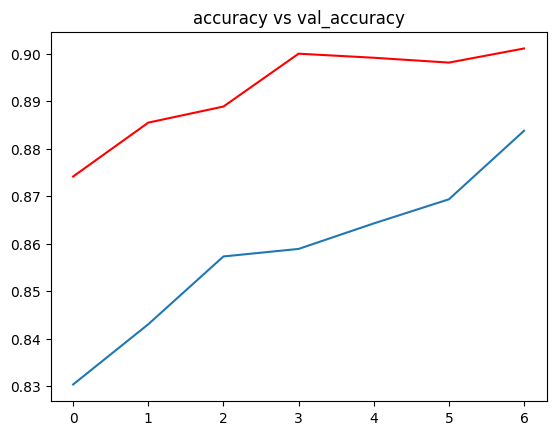

In [ ]:
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'], c='red')
plt.title('accuracy vs val_accuracy')
plt.show()

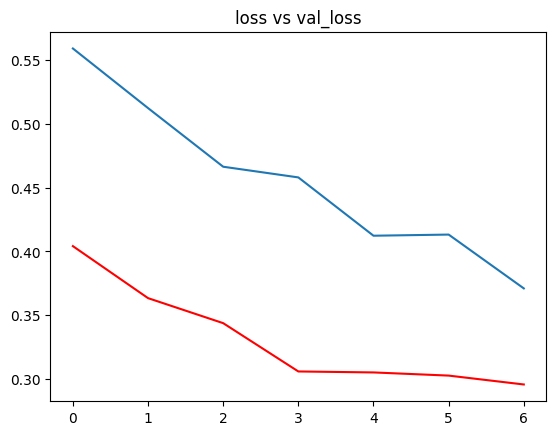

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'], c='red')
plt.title('loss vs val_loss')
plt.show()

In [ ]:
#load best model
from keras.models import load_model

model= load_model('/content/best_model(VGG19).keras')

In [ ]:
acc = model.evaluate(val)[1]

print(f"The accuracy of the model = {acc*100} %")

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


275/275 ━━━━━━━━━━━━━━━━━━━━ 120s 354ms/step - accuracy: 0.9009 - loss: 2.5006
The accuracy of the model = 90.12633562088013 %


In [ ]:
#Creating dictionaries of Classes
ref= dict(zip(list(train.class_indices.values()),list(train.class_indices.keys())))
for i in ref:
  print(ref[i])

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy


In [ ]:
def prediction(path):
  img= load_img(path, target_size=(224,224))
  i = img_to_array(img)
  im=preprocess_input(i)
  img= np.expand_dims(im, axis= 0)
  pred = np.argmax(model.predict(img))
  print(f'the image belongs to {ref[pred]}')

In [ ]:
path=('/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Grape___Black_rot/004175d8-dc74-4285-8401-3cc9565730bb___FAM_B.Rot 0626.JPG')
prediction(path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
the image belongs to Grape___Black_rot


In [ ]:
def prediction(path):
    img = load_img(path, target_size=(224,224))
    i = img_to_array(img)
    im = preprocess_input(i)
    img = np.expand_dims(im, axis=0)
    pred = np.argmax(model.predict(img))
    print(f'The image belongs to {ref[pred]}')

# Testing with a sample image
path = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Grape___Black_rot/004175d8-dc74-4285-8401-3cc9565730bb___FAM_B.Rot 0626.JPG'
prediction(path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
The image belongs to Grape___Black_rot


#VGG16

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

In [ ]:
len(os.listdir('/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'))

38

In [ ]:
train_datagen = ImageDataGenerator(zoom_range= 0.5, shear_range= 0.3,
                                   horizontal_flip= True,
                                   preprocessing_function= preprocess_input)

val_datagen = ImageDataGenerator(preprocessing_function= preprocess_input)

train = train_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
                                          target_size=(224,224),
                                          batch_size=64)

val = val_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
                                          target_size=(224,224),
                                          batch_size=64)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


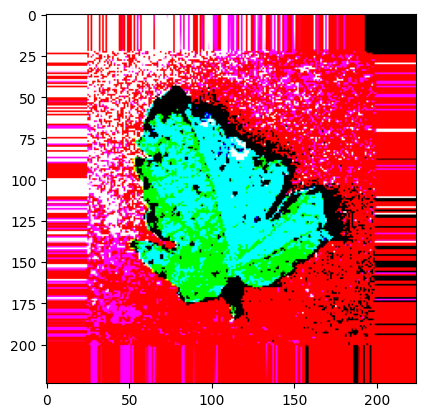

<Figure size 500x500 with 0 Axes>

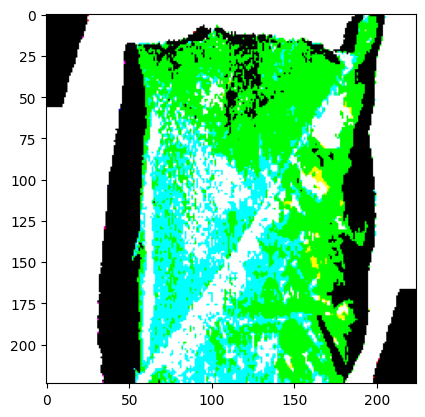

<Figure size 500x500 with 0 Axes>

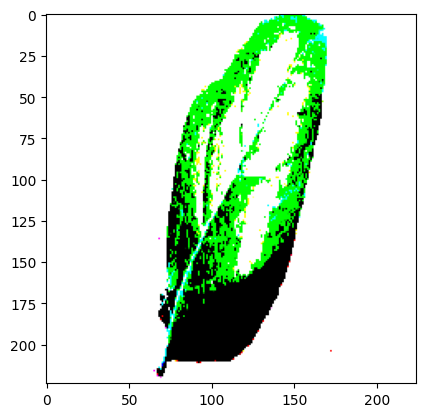

<Figure size 500x500 with 0 Axes>

In [ ]:
t_img, label = next(train)

def plotImage(img_arr,label):
    for im, l in zip(img_arr,label):
        plt.imshow(im)
        plt.figure(figsize=(5,5))
        plt.show()

plotImage(t_img[:3], label[:3])

In [ ]:
# Building the model
from keras.layers import Dense, Flatten
from keras.models import Model

base_model = VGG16(input_shape=(224,224,3), include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

X = Flatten()(base_model.output)
X = Dense(units=38, activation='softmax')(X)

In [ ]:
model = Model(base_model.input, X)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │         953,382 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 15,668,070 (59.77 MB)

 Trainable params: 953,382 (3.64 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

# Early stopping
es = EarlyStopping(monitor='val_accuracy', min_delta=0.01, patience=3, verbose=1)

# Model checkpoint
mc = ModelCheckpoint(filepath="best_model(VGG16).keras", monitor='val_accuracy', verbose=1, save_best_only=True)

cb = [es, mc]

In [ ]:
his = model.fit(train,
                steps_per_epoch=64,
                epochs=50,
                verbose=1,
                callbacks=cb,
                validation_data=val,
                validation_steps=64)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.3222 - loss: 16.7675
Epoch 1: val_accuracy improved from -inf to 0.77466, saving model to best_model(VGG16).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.3249 - loss: 16.6788 - val_accuracy: 0.7747 - val_loss: 4.2054
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 848ms/step - accuracy: 0.7025 - loss: 5.7800
Epoch 2: val_accuracy improved from 0.77466 to 0.81250, saving model to best_model(VGG16).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.7028 - loss: 5.7750 - val_accuracy: 0.8125 - val_loss: 3.3319
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.7615 - loss: 4.6009
Epoch 3: val_accuracy improved from 0.81250 to 0.83813, saving model to best_model(VGG16).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.7617 - loss: 4.5987 - val_accuracy: 0.8381 - val_loss: 3.3461
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.7977 - loss: 4.1450
Epoch 4: val_accuracy did not impr

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


64/64 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8069 - loss: 4.0095 - val_accuracy: 0.8392 - val_loss: 3.6881
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.8291 - loss: 4.1451
Epoch 6: val_accuracy improved from 0.83923 to 0.86182, saving model to best_model(VGG16).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8291 - loss: 4.1456 - val_accuracy: 0.8618 - val_loss: 3.4146
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.8333 - loss: 4.1472
Epoch 7: val_accuracy improved from 0.86182 to 0.87476, saving model to best_model(VGG16).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8332 - loss: 4.1473 - val_accuracy: 0.8748 - val_loss: 3.0299
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.8372 - loss: 3.9836
Epoch 8: val_accuracy improved from 0.87476 to 0.89062, saving model to best_model(VGG16).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8372 - loss: 3.9843 - val_accuracy: 0.8906 - val_loss: 2

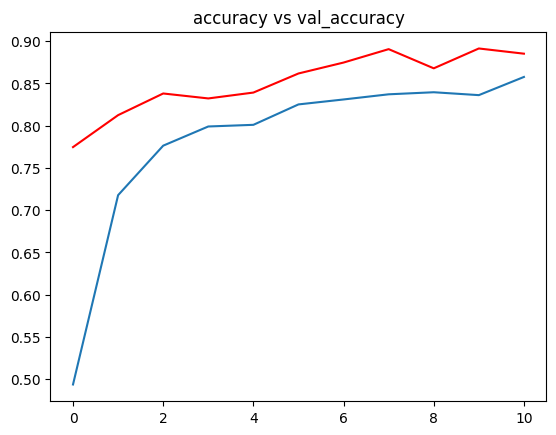

In [ ]:
h = his.history
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'], c='red')
plt.title('accuracy vs val_accuracy')
plt.show()

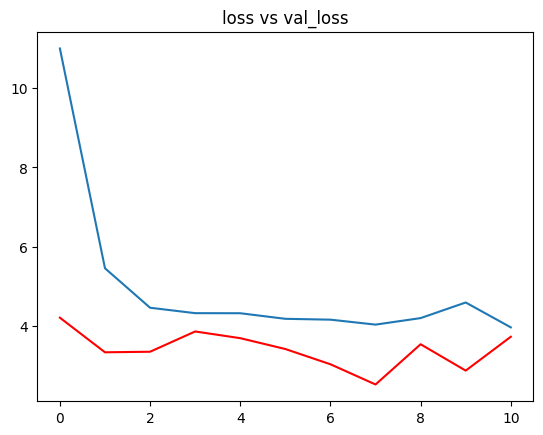

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'], c='red')
plt.title('loss vs val_loss')
plt.show()

In [ ]:
# Load best model
from keras.models import load_model

model = load_model('/content/best_model(VGG16).keras')

acc = model.evaluate(val)[1]
print(f"The accuracy of the model = {acc*100} %")

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


275/275 ━━━━━━━━━━━━━━━━━━━━ 109s 318ms/step - accuracy: 0.8871 - loss: 3.0634
The accuracy of the model = 89.1930341720581 %


In [ ]:
#Creating dictionaries of Classes
ref= dict(zip(list(train.class_indices.values()),list(train.class_indices.keys())))

#ResNet50

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50, preprocess_input

In [ ]:
len(os.listdir('/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'))

38

In [ ]:
# Data Generation
train_datagen = ImageDataGenerator(zoom_range= 0.5, shear_range= 0.3,
                                   horizontal_flip= True,
                                   preprocessing_function= preprocess_input)

val_datagen = ImageDataGenerator(preprocessing_function= preprocess_input)

In [ ]:
train = train_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
                                          target_size=(224,224),
                                          batch_size=64)

val = val_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
                                          target_size=(224,224),
                                          batch_size=64)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


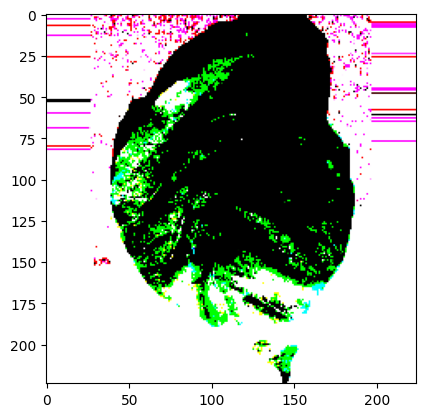

<Figure size 500x500 with 0 Axes>

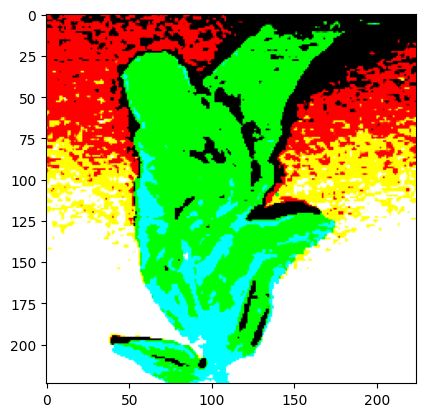

<Figure size 500x500 with 0 Axes>

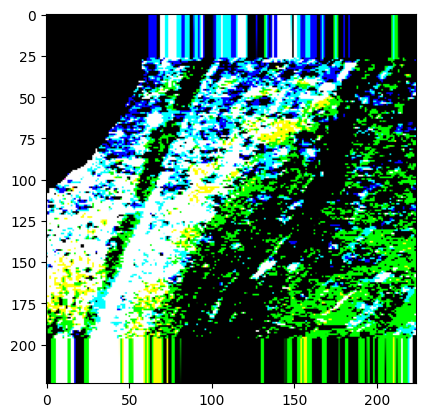

<Figure size 500x500 with 0 Axes>

In [ ]:
t_img, label = next(train)

def plotImage(img_arr,label):
    for im, l in zip(img_arr,label):
        plt.imshow(im)
        plt.figure(figsize=(5,5))
        plt.show()

plotImage(t_img[:3], label[:3])

In [ ]:
from keras.layers import Dense, Flatten
from keras.models import Model

In [ ]:
# Building the model
base_model = ResNet50(input_shape=(224,224,3), include_top=False)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
X = Flatten()(base_model.output)
X = Dense(units=38, activation='softmax')(X)

In [ ]:
model = Model(base_model.input, X)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

# Early stopping
es = EarlyStopping(monitor='val_accuracy', min_delta=0.01, patience=3, verbose=1)

# Model checkpoint
mc = ModelCheckpoint(filepath="best_model(ResNet).keras", monitor='val_accuracy', verbose=1, save_best_only=True)

cb = [es, mc]

In [ ]:
# Training the model
his = model.fit(train,
                steps_per_epoch=64,
                epochs=50,
                verbose=1,
                callbacks=cb,
                validation_data=val,
                validation_steps=64)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.3792 - loss: 15.6799
Epoch 1: val_accuracy improved from -inf to 0.82788, saving model to best_model(ResNet).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.3821 - loss: 15.5919 - val_accuracy: 0.8279 - val_loss: 2.6535
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 859ms/step - accuracy: 0.7787 - loss: 4.3831
Epoch 2: val_accuracy improved from 0.82788 to 0.83447, saving model to best_model(ResNet).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.7787 - loss: 4.3870 - val_accuracy: 0.8345 - val_loss: 3.0959
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 845ms/step - accuracy: 0.7907 - loss: 4.3835
Epoch 3: val_accuracy improved from 0.83447 to 0.84741, saving model to best_model(ResNet).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.7909 - loss: 4.3838 - val_accuracy: 0.8474 - val_loss: 3.0216
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - accuracy: 0.8117 - loss: 4.5347
Epoch 4: val_accuracy improved 

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8553 - loss: 3.6101 - val_accuracy: 0.8990 - val_loss: 2.3112
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.8543 - loss: 3.7945
Epoch 6: val_accuracy improved from 0.89899 to 0.90869, saving model to best_model(ResNet).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.8544 - loss: 3.7914 - val_accuracy: 0.9087 - val_loss: 2.2428
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.8775 - loss: 2.8860
Epoch 7: val_accuracy did not improve from 0.90869
64/64 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8776 - loss: 2.8857 - val_accuracy: 0.8813 - val_loss: 2.5580
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.8681 - loss: 3.3951
Epoch 8: val_accuracy improved from 0.90869 to 0.92773, saving model to best_model(ResNet).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.8682 - loss: 3.3936 - val_accuracy: 0.9277 - val_loss: 1.6901
Epoch 9/50
64/64 ━━━━━━━━━━━━━━━━━━━━

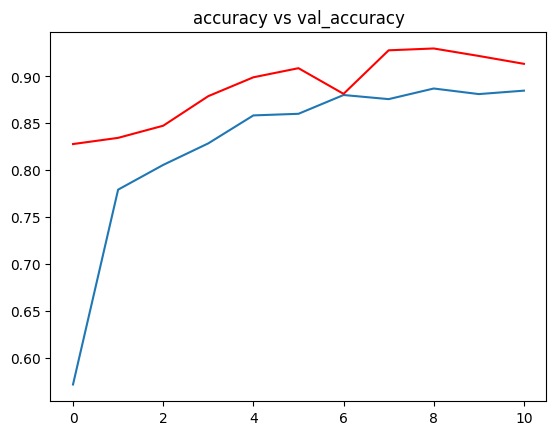

In [ ]:
# Plotting accuracy and loss
h = his.history
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'], c='red')
plt.title('accuracy vs val_accuracy')
plt.show()

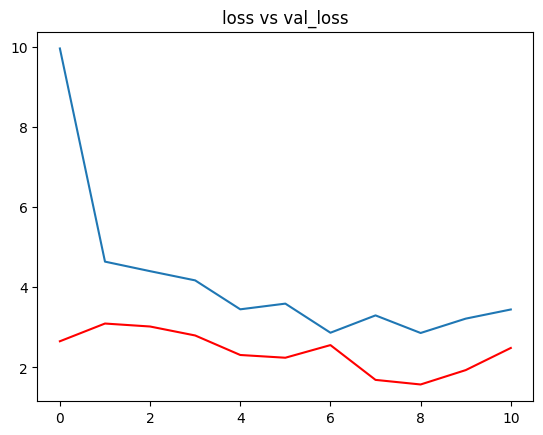

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'], c='red')
plt.title('loss vs val_loss')
plt.show()

In [ ]:
# Load best model
from keras.models import load_model

model = load_model('/content/best_model(ResNet).keras')

acc = model.evaluate(val)[1]
print(f"The accuracy of the model = {acc*100} %")

275/275 ━━━━━━━━━━━━━━━━━━━━ 64s 214ms/step - accuracy: 0.9239 - loss: 1.9356
The accuracy of the model = 92.35146641731262 %


In [ ]:
# Creating dictionaries of Classes
ref = dict(zip(list(train.class_indices.values()), list(train.class_indices.keys())))
for i in ref:
    print(ref[i])

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy


In [ ]:
# Prediction function
def prediction(path):
    img = load_img(path, target_size=(224,224))
    i = img_to_array(img)
    im = preprocess_input(i)
    img = np.expand_dims(im, axis=0)
    pred = np.argmax(model.predict(img))
    print(f'The image belongs to {ref[pred]}')

# Testing with a sample image
path = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Grape___Black_rot/004175d8-dc74-4285-8401-3cc9565730bb___FAM_B.Rot 0626.JPG'
prediction(path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
The image belongs to Grape___Black_rot


#ResNet152

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet152, preprocess_input

In [ ]:
# Data Generation
train_datagen = ImageDataGenerator(zoom_range=0.5, shear_range=0.3,
                                   horizontal_flip=True,
                                   preprocessing_function=preprocess_input)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train = train_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
                                          target_size=(224, 224),
                                          batch_size=64)

val = val_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
                                      target_size=(224, 224),
                                      batch_size=64)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


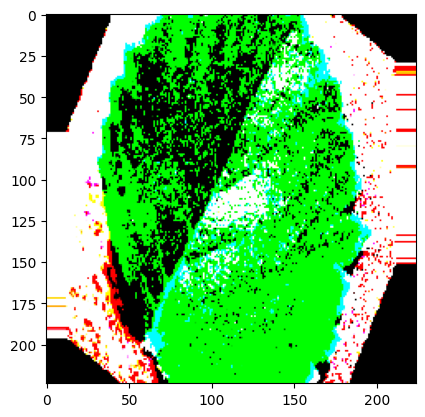

<Figure size 500x500 with 0 Axes>

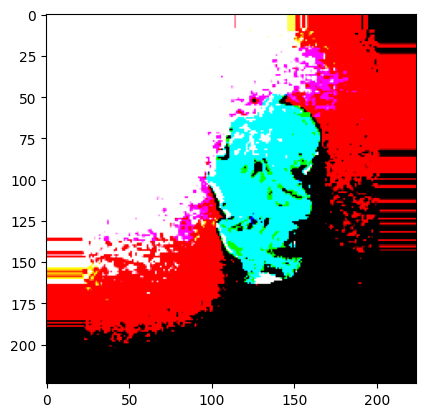

<Figure size 500x500 with 0 Axes>

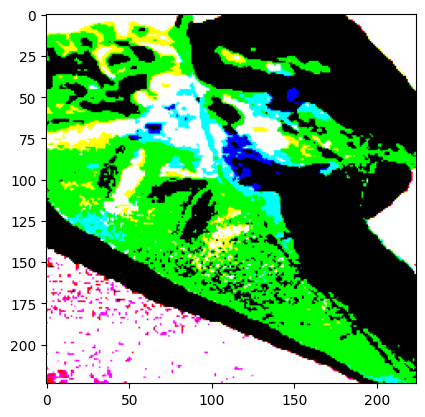

<Figure size 500x500 with 0 Axes>

In [ ]:
t_img, label = next(train)

def plotImage(img_arr, label):
    for im, l in zip(img_arr, label):
        plt.imshow(im)
        plt.figure(figsize=(5, 5))
        plt.show()

plotImage(t_img[:3], label[:3])

In [ ]:
# Building the model
from keras.layers import Dense, Flatten
from keras.models import Model

base_model = ResNet152(input_shape=(224, 224, 3), include_top=False)

for layer in base_model.layers:
    layer.trainable = False

X = Flatten()(base_model.output)
X = Dense(units=38, activation='softmax')(X)

234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Creating the model
model = Model(base_model.input, X)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

# Early stopping
es = EarlyStopping(monitor='val_accuracy', min_delta=0.01, patience=3, verbose=1)

# Model checkpoint
mc = ModelCheckpoint(filepath="best_model(ResNet152).keras", monitor='val_accuracy', verbose=1, save_best_only=True)

cb = [es, mc]

In [ ]:
# Training the model
his = model.fit(train,
                steps_per_epoch=64,
                epochs=50,
                verbose=1,
                callbacks=cb,
                validation_data=val,
                validation_steps=64)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3715 - loss: 19.4513
Epoch 1: val_accuracy improved from -inf to 0.82104, saving model to best_model(ResNet152).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.3745 - loss: 19.3283 - val_accuracy: 0.8210 - val_loss: 2.7359
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 935ms/step - accuracy: 0.7624 - loss: 4.7145
Epoch 2: val_accuracy improved from 0.82104 to 0.84839, saving model to best_model(ResNet152).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.7628 - loss: 4.7053 - val_accuracy: 0.8484 - val_loss: 2.4420
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.8158 - loss: 3.6820
Epoch 3: val_accuracy improved from 0.84839 to 0.88184, saving model to best_model(ResNet152).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.8160 - loss: 3.6804 - val_accuracy: 0.8818 - val_loss: 2.2418
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 897ms/step - accuracy: 0.8278 - loss: 3.9800
Epoch 4: val_accuracy did

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


64/64 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8511 - loss: 3.6354 - val_accuracy: 0.8948 - val_loss: 2.3330
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 916ms/step - accuracy: 0.8597 - loss: 3.3947
Epoch 6: val_accuracy improved from 0.89478 to 0.90674, saving model to best_model(ResNet152).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.8598 - loss: 3.3915 - val_accuracy: 0.9067 - val_loss: 2.2537
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 917ms/step - accuracy: 0.8733 - loss: 3.1705
Epoch 7: val_accuracy did not improve from 0.90674
64/64 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.8733 - loss: 3.1717 - val_accuracy: 0.8794 - val_loss: 3.0446
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 909ms/step - accuracy: 0.8672 - loss: 3.8269
Epoch 8: val_accuracy improved from 0.90674 to 0.91235, saving model to best_model(ResNet152).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.8674 - loss: 3.8238 - val_accuracy: 0.9124 - val_loss: 2.1663
Epoch 9/50
64/64 ━━━━━━━━━━━━━━

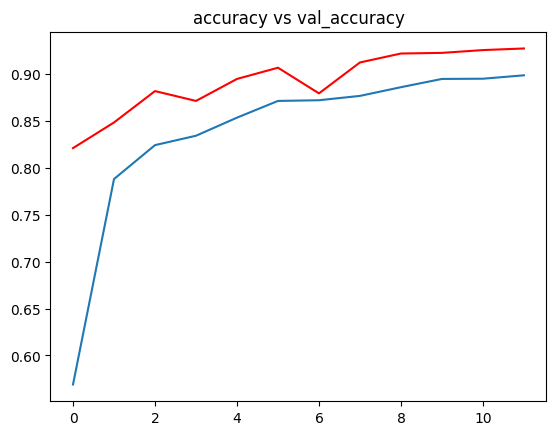

In [ ]:
# Plotting accuracy and loss
h = his.history
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'], c='red')
plt.title('accuracy vs val_accuracy')
plt.show()

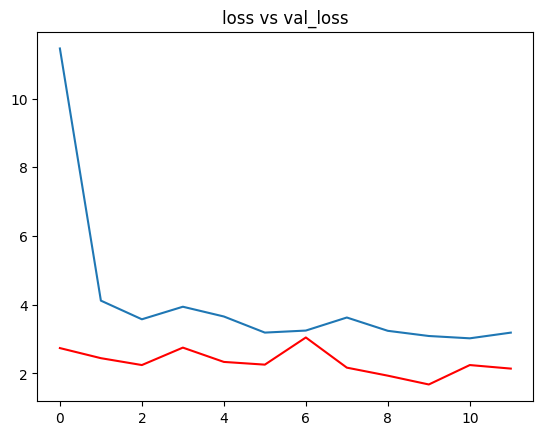

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'], c='red')
plt.title('loss vs val_loss')
plt.show()

In [ ]:
from keras.models import load_model

model = load_model('/content/best_model(ResNet152).keras')

In [ ]:
acc = model.evaluate(val)[1]
print(f"The accuracy of the model = {acc*100} %")

275/275 ━━━━━━━━━━━━━━━━━━━━ 129s 419ms/step - accuracy: 0.9310 - loss: 2.1613
The accuracy of the model = 93.10835599899292 %


In [ ]:
ref = dict(zip(list(train.class_indices.values()), list(train.class_indices.keys())))
for i in ref:
    print(ref[i])

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy


In [ ]:
# Prediction function
def prediction(path):
    img = load_img(path, target_size=(224, 224))
    i = img_to_array(img)
    im = preprocess_input(i)
    img = np.expand_dims(im, axis=0)
    pred = np.argmax(model.predict(img))
    print(f'The image belongs to {ref[pred]}')

# Testing with a sample image
path = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Grape___Black_rot/004175d8-dc74-4285-8401-3cc9565730bb___FAM_B.Rot 0626.JPG'
prediction(path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
The image belongs to Grape___Black_rot


#MobileNet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet import MobileNet, preprocess_input

In [ ]:
train_datagen = ImageDataGenerator(zoom_range=0.5, shear_range=0.3,
                                   horizontal_flip=True,
                                   preprocessing_function=preprocess_input)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train = train_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
                                          target_size=(224,224),
                                          batch_size=64)

val = val_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
                                      target_size=(224,224),
                                      batch_size=64)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


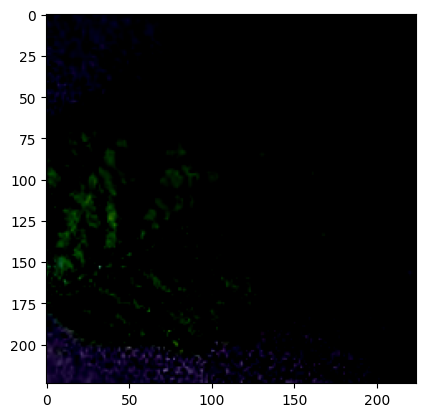

<Figure size 500x500 with 0 Axes>

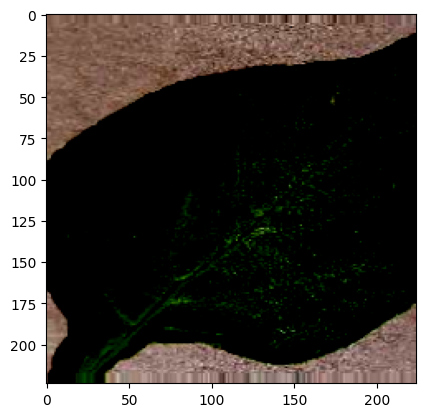

<Figure size 500x500 with 0 Axes>

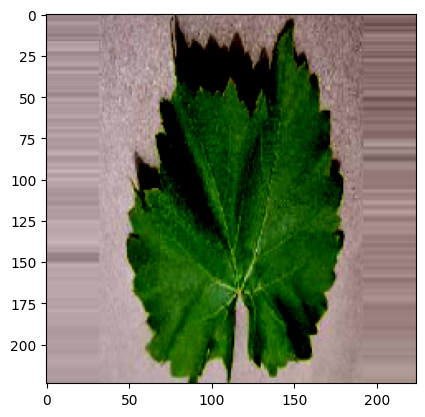

<Figure size 500x500 with 0 Axes>

In [ ]:
t_img, label = next(train)

def plotImage(img_arr, label):
    for im, l in zip(img_arr, label):
        plt.imshow(im)
        plt.figure(figsize=(5, 5))
        plt.show()

plotImage(t_img[:3], label[:3])


In [ ]:
from keras.layers import Dense, Flatten
from keras.models import Model

base_model = MobileNet(input_shape=(224,224,3), include_top=False)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.summary()

Model: "mobilenet_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 112, 112, 32)        │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_bn (BatchNormalization)        │ (None, 112, 112, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_relu (ReLU)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1 (DepthwiseConv2D)          │ (None, 112, 112, 32)        │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_bn (BatchNormalization)    │ (None, 112, 112, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_relu (ReLU)                │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1 (Conv2D)                   │ (None, 112, 112, 64)        │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_bn (BatchNormalization)    │ (None, 112, 112, 64)        │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_relu (ReLU)                │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pad_2 (ZeroPadding2D)           │ (None, 113, 113, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2 (DepthwiseConv2D)          │ (None, 56, 56, 64)          │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_bn (BatchNormalization)    │ (None, 56, 56, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_relu (ReLU)                │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2 (Conv2D)                   │ (None, 56, 56, 128)         │           8,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_bn (BatchNormalization)    │ (None, 56, 56, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_relu (ReLU)                │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3 (DepthwiseConv2D)          │ (None, 56, 56, 128)         │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_bn (BatchNormalization)    │ (None, 56, 56, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_relu (ReLU)                │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_3 (Conv2D)                   │ (None, 56, 56, 128)         │          16,384 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 3,228,864 (12.32 MB)

 Trainable params: 3,206,976 (12.23 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

X = Flatten()(base_model.output)
X = Dense(units=38, activation='softmax')(X)

In [ ]:
# Creating the model
model = Model(base_model.input, X)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

# Early stopping
es = EarlyStopping(monitor='val_accuracy', min_delta=0.01, patience=5, verbose=1)

# Model checkpoint
mc = ModelCheckpoint(filepath="best_model(MobileNet).keras", monitor='val_accuracy', verbose=1, save_best_only=True)

cb = [es, mc]

In [ ]:
his = model.fit(train,
                steps_per_epoch=64,
                epochs=50,
                verbose=1,
                callbacks=cb,
                validation_data=val,
                validation_steps=64)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.8597 - loss: 1.9279
Epoch 1: val_accuracy improved from -inf to 0.89624, saving model to best_model(MobileNet).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 907ms/step - accuracy: 0.8596 - loss: 1.9300 - val_accuracy: 0.8962 - val_loss: 1.3393
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.8682 - loss: 2.1010
Epoch 2: val_accuracy improved from 0.89624 to 0.91162, saving model to best_model(MobileNet).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 913ms/step - accuracy: 0.8681 - loss: 2.1022 - val_accuracy: 0.9116 - val_loss: 1.1811
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.8678 - loss: 2.1581
Epoch 3: val_accuracy did not improve from 0.91162
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 887ms/step - accuracy: 0.8678 - loss: 2.1593 - val_accuracy: 0.8997 - val_loss: 1.3655
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - accuracy: 0.8801 - loss: 2.0180
Epoch 4: val_accuracy did not improve from 0.91162
64/

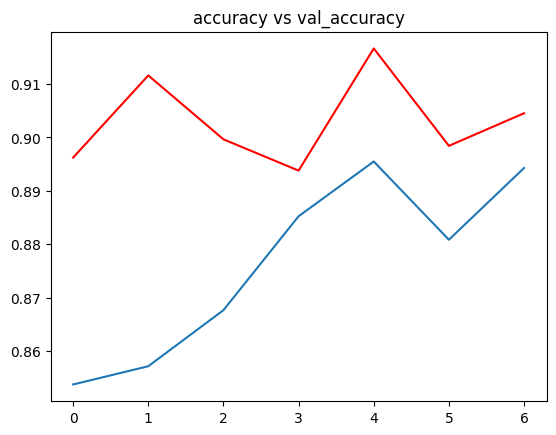

In [ ]:
h = his.history
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'], c='red')
plt.title('accuracy vs val_accuracy')
plt.show()

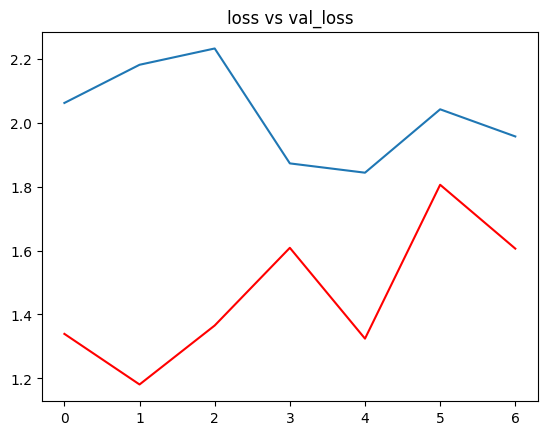

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'], c='red')
plt.title('loss vs val_loss')
plt.show()

In [ ]:
from keras.models import load_model

model = load_model('/content/best_model(MobileNet).keras')

acc = model.evaluate(val)[1]
print(f"The accuracy of the model = {acc*100} %")

275/275 ━━━━━━━━━━━━━━━━━━━━ 45s 152ms/step - accuracy: 0.9130 - loss: 1.4181
The accuracy of the model = 91.25881791114807 %


In [ ]:
def prediction(path):
    img = load_img(path, target_size=(224,224))
    i = img_to_array(img)
    im = preprocess_input(i)
    img = np.expand_dims(im, axis=0)
    pred = np.argmax(model.predict(img))
    print(f'The image belongs to {ref[pred]}')

# Testing with a sample image
path = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Grape___Black_rot/004175d8-dc74-4285-8401-3cc9565730bb___FAM_B.Rot 0626.JPG'
prediction(path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
The image belongs to Grape___Black_rot


#MobileNetV2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

In [ ]:
# Data Generation
train_datagen = ImageDataGenerator(zoom_range=0.5, shear_range=0.3,
                                   horizontal_flip=True,
                                   preprocessing_function=preprocess_input)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train = train_datagen.flow_from_directory(
    directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    target_size=(224, 224),
    batch_size=64)

val = val_datagen.flow_from_directory(
    directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    target_size=(224, 224),
    batch_size=64)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


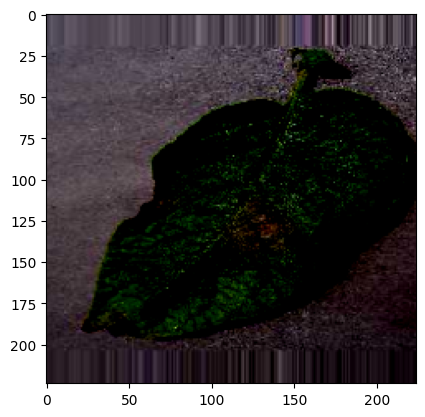

<Figure size 500x500 with 0 Axes>

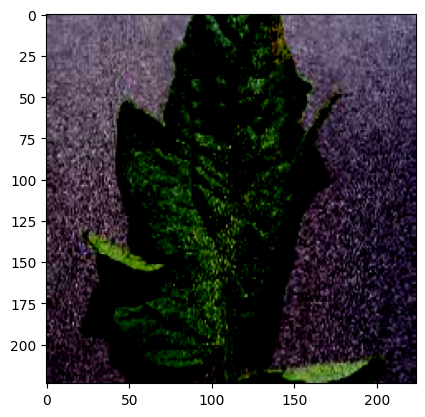

<Figure size 500x500 with 0 Axes>

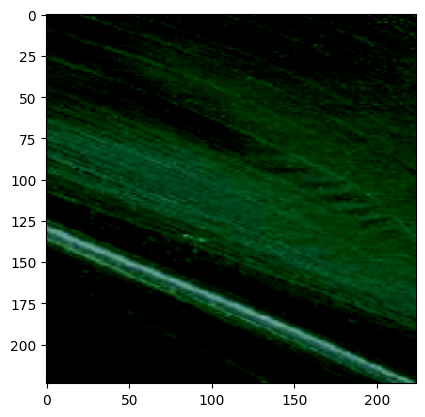

<Figure size 500x500 with 0 Axes>

In [ ]:
# Display sample images
t_img, label = next(train)

def plotImage(img_arr, label):
    for im, l in zip(img_arr, label):
        plt.imshow(im)
        plt.figure(figsize=(5, 5))
        plt.show()

plotImage(t_img[:3], label[:3])

In [ ]:
# Building the model with MobileNetV2
from keras.layers import Dense, Flatten
from keras.models import Model

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False)

# Freezing the base model layers
for layer in base_model.layers:
    layer.trainable = False

X = Flatten()(base_model.output)
X = Dense(units=38, activation='softmax')(X)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Creating the final model
model = Model(base_model.input, X)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

# Early stopping and model checkpointing
es = EarlyStopping(monitor='val_accuracy', min_delta=0.01, patience=3, verbose=1)
mc = ModelCheckpoint(filepath="best_model(MobileNetV2).keras", monitor='val_accuracy', verbose=1, save_best_only=True)

cb = [es, mc]

In [ ]:
# Training the model
his = model.fit(train,
                steps_per_epoch=64,
                epochs=50,
                verbose=1,
                callbacks=cb,
                validation_data=val,
                validation_steps=64)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - accuracy: 0.3871 - loss: 10.8499
Epoch 1: val_accuracy improved from -inf to 0.78369, saving model to best_model(MobileNetV2).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.3896 - loss: 10.7887 - val_accuracy: 0.7837 - val_loss: 1.9801
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 844ms/step - accuracy: 0.7604 - loss: 2.5756
Epoch 2: val_accuracy improved from 0.78369 to 0.79712, saving model to best_model(MobileNetV2).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 993ms/step - accuracy: 0.7606 - loss: 2.5746 - val_accuracy: 0.7971 - val_loss: 2.3065
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.7801 - loss: 2.6224
Epoch 3: val_accuracy improved from 0.79712 to 0.81641, saving model to best_model(MobileNetV2).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 979ms/step - accuracy: 0.7802 - loss: 2.6224 - val_accuracy: 0.8164 - val_loss: 2.2476
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.8016 - loss: 2.6460


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 878ms/step - accuracy: 0.8053 - loss: 2.8966 - val_accuracy: 0.8165 - val_loss: 2.4608
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.8121 - loss: 3.1020
Epoch 6: val_accuracy improved from 0.81650 to 0.87085, saving model to best_model(MobileNetV2).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 961ms/step - accuracy: 0.8122 - loss: 3.1013 - val_accuracy: 0.8708 - val_loss: 1.8274
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.8323 - loss: 2.9987
Epoch 7: val_accuracy improved from 0.87085 to 0.88208, saving model to best_model(MobileNetV2).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 956ms/step - accuracy: 0.8323 - loss: 2.9976 - val_accuracy: 0.8821 - val_loss: 1.7567
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.8545 - loss: 2.4683
Epoch 8: val_accuracy did not improve from 0.88208
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 941ms/step - accuracy: 0.8545 - loss: 2.4668 - val_accuracy: 0.8779 - val_loss: 2.1293
Epoch 9/50
64/6

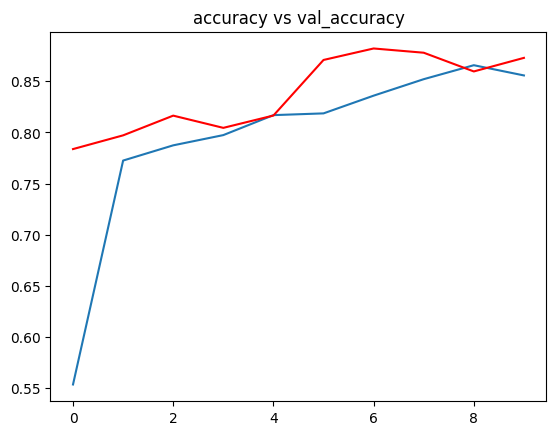

In [ ]:
# Plotting accuracy and loss
h = his.history
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'], c='red')
plt.title('accuracy vs val_accuracy')
plt.show()

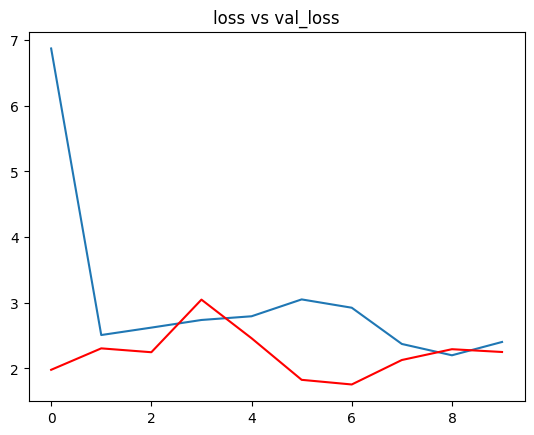

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'], c='red')
plt.title('loss vs val_loss')
plt.show()

In [ ]:
# Load best model
from keras.models import load_model

model = load_model('/content/best_model(MobileNetV2).keras')

In [ ]:
acc = model.evaluate(val)[1]
print(f"The accuracy of the model = {acc*100} %")

275/275 ━━━━━━━━━━━━━━━━━━━━ 46s 149ms/step - accuracy: 0.8746 - loss: 1.8832
The accuracy of the model = 87.47439384460449 %


In [ ]:
# Creating dictionaries of Classes
ref = dict(zip(list(train.class_indices.values()), list(train.class_indices.keys())))
for i in ref:
    print(ref[i])

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy


In [ ]:
# Prediction function
def prediction(path):
    img = load_img(path, target_size=(224, 224))
    i = img_to_array(img)
    im = preprocess_input(i)
    img = np.expand_dims(im, axis=0)
    pred = np.argmax(model.predict(img))
    print(f'The image belongs to {ref[pred]}')

# Testing with a sample image
path = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Grape___Black_rot/004175d8-dc74-4285-8401-3cc9565730bb___FAM_B.Rot 0626.JPG'
prediction(path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
The image belongs to Grape___Black_rot


#Inception V3

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

In [ ]:
# Data Generation
train_datagen = ImageDataGenerator(zoom_range=0.5, shear_range=0.3,
                                   horizontal_flip=True,
                                   preprocessing_function=preprocess_input)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train = train_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
                                          target_size=(299,299),
                                          batch_size=64)

val = val_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
                                      target_size=(299,299),
                                      batch_size=64)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


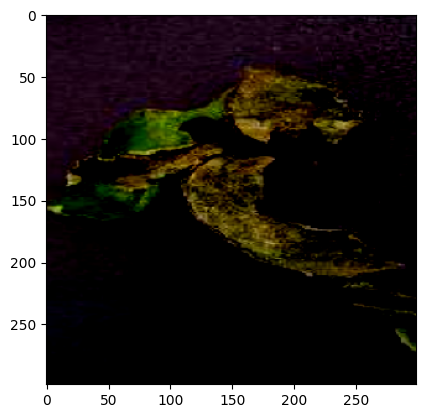

<Figure size 500x500 with 0 Axes>

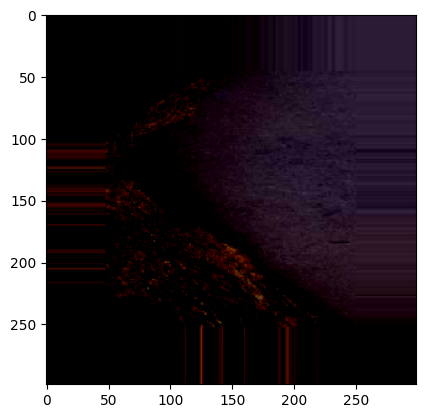

<Figure size 500x500 with 0 Axes>

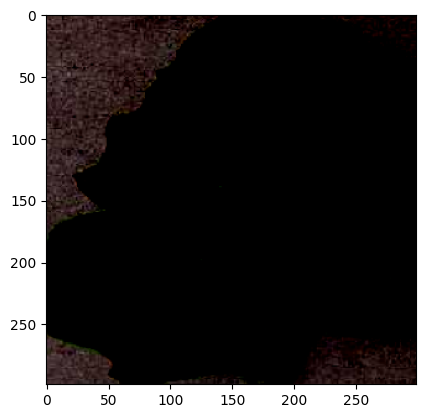

<Figure size 500x500 with 0 Axes>

In [ ]:
t_img, label = next(train)

def plotImage(img_arr, label):
    for im, l in zip(img_arr, label):
        plt.imshow(im)
        plt.figure(figsize=(5, 5))
        plt.show()

plotImage(t_img[:3], label[:3])

In [ ]:
from keras.layers import Dense, Flatten
from keras.models import Model

base_model = InceptionV3(input_shape=(299,299,3), include_top=False)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 299, 299, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 149, 149, 32)   │            864 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 149, 149, 32)   │             96 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 149, 149, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 147, 147, 32)   │          9,216 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 147, 147, 32)   │             96 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 147, 147, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 147, 147, 64)   │         18,432 │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 147, 147, 64)   │            192 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 147, 147, 64)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 73, 73, 64)     │              0 │ activation_2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 73, 73, 80)     │          5,120 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 73, 73, 80)     │            240 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 73, 73, 80)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 71, 71, 192)    │        138,240 │ activation_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 71, 71, 192)    │            576 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

X = Flatten()(base_model.output)
X = Dense(units=38, activation='softmax')(X)

In [ ]:
model = Model(base_model.input, X)

In [ ]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 299, 299, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 149, 149, 32)   │            864 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 149, 149, 32)   │             96 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 149, 149, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 147, 147, 32)   │          9,216 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 147, 147, 32)   │             96 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 147, 147, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 147, 147, 64)   │         18,432 │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 147, 147, 64)   │            192 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 147, 147, 64)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 73, 73, 64)     │              0 │ activation_2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 73, 73, 80)     │          5,120 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 73, 73, 80)     │            240 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 73, 73, 80)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 71, 71, 192)    │        138,240 │ activation_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 71, 71, 192)    │            576 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 26,783,558 (102.17 MB)

 Trainable params: 4,980,774 (19.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

# Early stopping
es = EarlyStopping(monitor='val_accuracy', min_delta=0.01, patience=3, verbose=1)

# Model checkpoint
mc = ModelCheckpoint(filepath="best_model(InceptionV3).keras", monitor='val_accuracy', verbose=1, save_best_only=True)

cb = [es, mc]

In [ ]:
his = model.fit(train,
                steps_per_epoch=64,
                epochs=50,
                verbose=1,
                callbacks=cb,
                validation_data=val,
                validation_steps=64)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2376 - loss: 35.1964
Epoch 1: val_accuracy improved from -inf to 0.69458, saving model to best_model(InceptionV3).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.2403 - loss: 34.9941 - val_accuracy: 0.6946 - val_loss: 3.9000
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6687 - loss: 5.1143
Epoch 2: val_accuracy improved from 0.69458 to 0.74634, saving model to best_model(InceptionV3).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.6689 - loss: 5.1131 - val_accuracy: 0.7463 - val_loss: 3.5696
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7222 - loss: 4.9732
Epoch 3: val_accuracy improved from 0.74634 to 0.78003, saving model to best_model(InceptionV3).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.7220 - loss: 4.9812 - val_accuracy: 0.7800 - val_loss: 3.1898
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7489 - loss: 4.3394
Epoch 4: val_accuracy did 

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


64/64 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.7680 - loss: 4.1004 - val_accuracy: 0.8241 - val_loss: 2.6911
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7985 - loss: 3.9593
Epoch 6: val_accuracy did not improve from 0.82407
64/64 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.7986 - loss: 3.9569 - val_accuracy: 0.8191 - val_loss: 2.8785
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7932 - loss: 4.1492
Epoch 7: val_accuracy did not improve from 0.82407
64/64 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.7931 - loss: 4.1546 - val_accuracy: 0.7754 - val_loss: 4.5847
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8044 - loss: 4.2928
Epoch 8: val_accuracy improved from 0.82407 to 0.82764, saving model to best_model(InceptionV3).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.8044 - loss: 4.2939 - val_accuracy: 0.8276 - val_loss: 3.2912
Epoch 8: early stopping


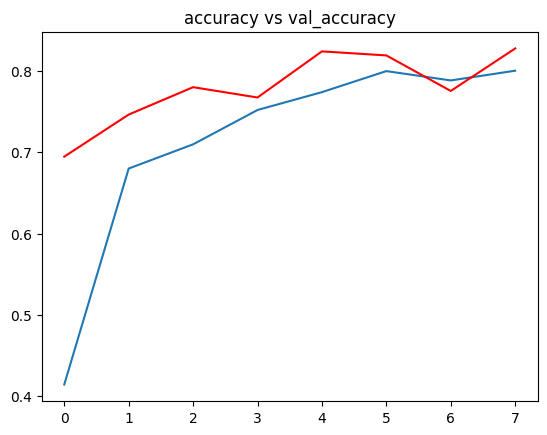

In [ ]:
h = his.history
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'], c='red')
plt.title('accuracy vs val_accuracy')
plt.show()

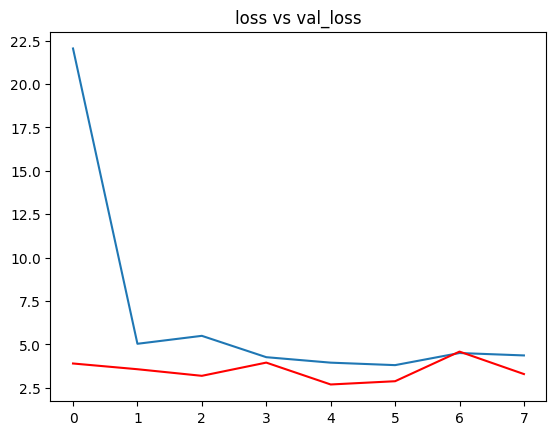

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'], c='red')
plt.title('loss vs val_loss')
plt.show()

In [ ]:
from keras.models import load_model

model = load_model('/content/best_model(InceptionV3).keras')

acc = model.evaluate(val)[1]
print(f"The accuracy of the model = {acc*100} %")

275/275 ━━━━━━━━━━━━━━━━━━━━ 79s 262ms/step - accuracy: 0.8302 - loss: 3.3320
The accuracy of the model = 82.81925916671753 %


In [ ]:
#Prediction function
def prediction(path):
    img = load_img(path, target_size=(299,299))
    i = img_to_array(img)
    im = preprocess_input(i)
    img = np.expand_dims(im, axis=0)
    pred = np.argmax(model.predict(img))
    print(f'The image belongs to {ref[pred]}')

# Testing with a sample image
path = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Grape___Black_rot/004175d8-dc74-4285-8401-3cc9565730bb___FAM_B.Rot 0626.JPG'
prediction(path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
The image belongs to Grape___Esca_(Black_Measles)


#Part2 is in sahilsaifi105073@gmail.com

#NASNetMobile

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.nasnet import NASNetMobile, preprocess_input

In [ ]:
# Data Generation
train_datagen = ImageDataGenerator(zoom_range=0.5, shear_range=0.3,
                                   horizontal_flip=True,
                                   preprocessing_function=preprocess_input)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train = train_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
                                          target_size=(224, 224),
                                          batch_size=64)

val = val_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
                                      target_size=(224, 224),
                                      batch_size=64)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


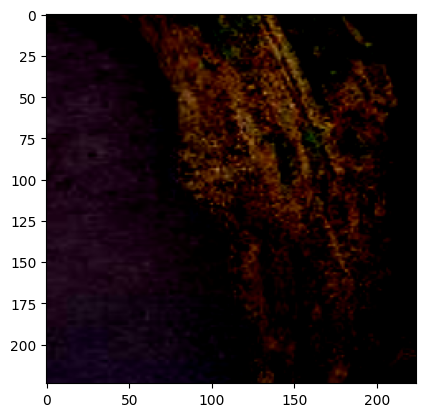

<Figure size 500x500 with 0 Axes>

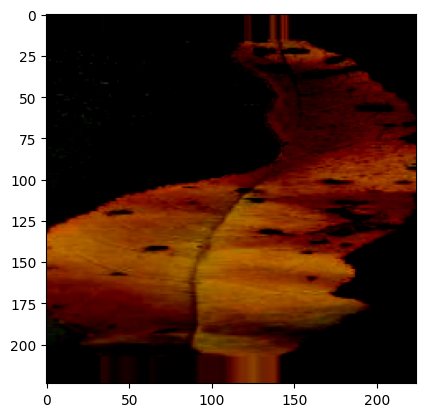

<Figure size 500x500 with 0 Axes>

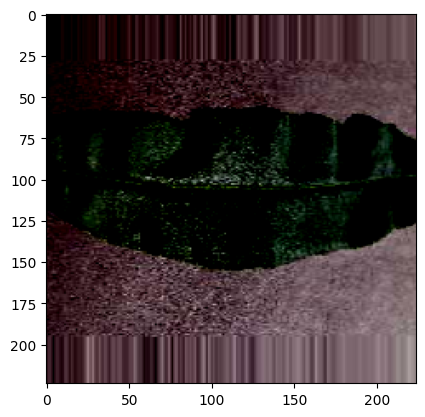

<Figure size 500x500 with 0 Axes>

In [ ]:
t_img, label = next(train)

def plotImage(img_arr, label):
    for im, l in zip(img_arr, label):
        plt.imshow(im)
        plt.figure(figsize=(5, 5))
        plt.show()

plotImage(t_img[:3], label[:3])

In [ ]:
# Building the model
from keras.layers import Dense, Flatten
from keras.models import Model

base_model = NASNetMobile(input_shape=(224, 224, 3), include_top=False)

for layer in base_model.layers:
    layer.trainable = False

X = Flatten()(base_model.output)
X = Dense(units=38, activation='softmax')(X)

19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Creating the model
model = Model(base_model.input, X)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

# Early stopping
es = EarlyStopping(monitor='val_accuracy', min_delta=0.01, patience=3, verbose=1)

# Model checkpoint
mc = ModelCheckpoint(filepath="best_model(NASNetMobile).keras", monitor='val_accuracy', verbose=1, save_best_only=True)

cb = [es, mc]


In [ ]:
his = model.fit(train,
                steps_per_epoch=64,
                epochs=50,
                verbose=1,
                callbacks=cb,
                validation_data=val,
                validation_steps=64)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.2487 - loss: 12.3968
Epoch 1: val_accuracy improved from -inf to 0.64307, saving model to best_model(NASNetMobile).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.2512 - loss: 12.3308 - val_accuracy: 0.6431 - val_loss: 2.6551
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 851ms/step - accuracy: 0.6305 - loss: 2.7268
Epoch 2: val_accuracy improved from 0.64307 to 0.66162, saving model to best_model(NASNetMobile).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.6307 - loss: 2.7244 - val_accuracy: 0.6616 - val_loss: 2.5814
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 878ms/step - accuracy: 0.6675 - loss: 2.5776
Epoch 3: val_accuracy improved from 0.66162 to 0.71729, saving model to best_model(NASNetMobile).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.6676 - loss: 2.5787 - val_accuracy: 0.7173 - val_loss: 2.6047
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.7190 - loss: 2.2978
Epoch 4: val_

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.7386 - loss: 2.4660
Epoch 6: val_accuracy improved from 0.73804 to 0.76562, saving model to best_model(NASNetMobile).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.7385 - loss: 2.4674 - val_accuracy: 0.7656 - val_loss: 2.1522
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - accuracy: 0.7537 - loss: 2.4914
Epoch 7: val_accuracy improved from 0.76562 to 0.79028, saving model to best_model(NASNetMobile).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7537 - loss: 2.4901 - val_accuracy: 0.7903 - val_loss: 1.8787
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.7559 - loss: 2.4568
Epoch 8: val_accuracy improved from 0.79028 to 0.81226, saving model to best_model(NASNetMobile).keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 989ms/step - accuracy: 0.7558 - loss: 2.4574 - val_accuracy: 0.8123 - val_loss: 1.6306
Epoch 9/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.7778 - loss: 2.2239
Epoch 9: v

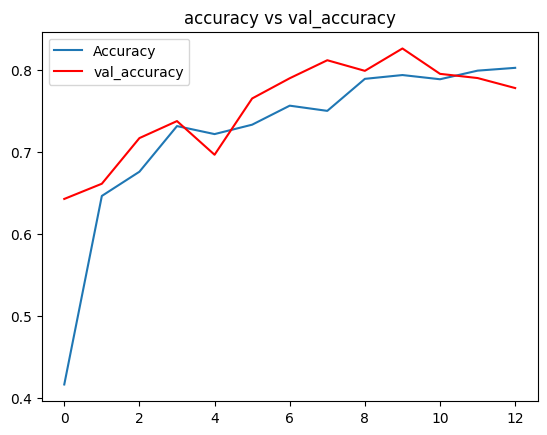

In [ ]:
# Plotting accuracy and loss
h = his.history
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'], c='red')
plt.title('accuracy vs val_accuracy')
plt.legend(["Accuracy", "val_accuracy"], loc='upper left')
plt.show()

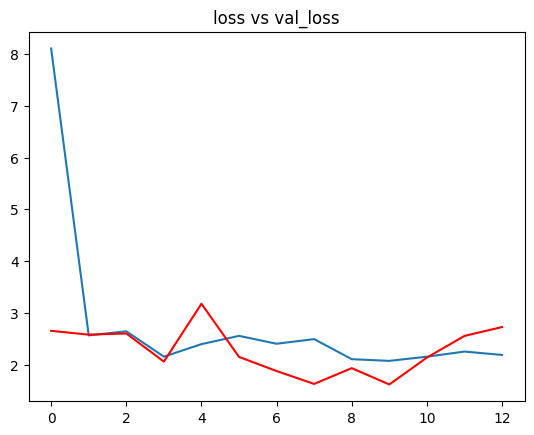

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'], c='red')
plt.title('loss vs val_loss')
plt.show()

In [ ]:
# Load best model
from keras.models import load_model

model = load_model('/content/best_model(NASNetMobile).keras')

acc = model.evaluate(val)[1]
print(f"The accuracy of the model = {acc*100} %")

275/275 ━━━━━━━━━━━━━━━━━━━━ 65s 179ms/step - accuracy: 0.8057 - loss: 1.8327
The accuracy of the model = 80.79330921173096 %


In [ ]:
ref = dict(zip(list(train.class_indices.values()), list(train.class_indices.keys())))
for i in ref:
    print(ref[i])

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy


In [ ]:
def prediction(path):
    img = load_img(path, target_size=(224, 224))
    i = img_to_array(img)
    im = preprocess_input(i)
    img = np.expand_dims(im, axis=0)
    pred = np.argmax(model.predict(img))
    print(f'The image belongs to {ref[pred]}')

# Testing with a sample image
path = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Grape___Black_rot/004175d8-dc74-4285-8401-3cc9565730bb___FAM_B.Rot 0626.JPG'
prediction(path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
The image belongs to Grape___Black_rot


#DenseNet201

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import DenseNet201, preprocess_input

In [ ]:
# Data Generation
train_datagen = ImageDataGenerator(zoom_range=0.5, shear_range=0.3,
                                   horizontal_flip=True,
                                   preprocessing_function=preprocess_input)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train = train_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
                                          target_size=(224, 224),
                                          batch_size=128)

val = val_datagen.flow_from_directory(directory='/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
                                      target_size=(224, 224),
                                      batch_size=128)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


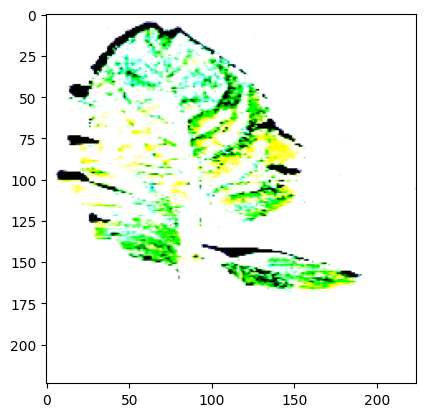

<Figure size 500x500 with 0 Axes>

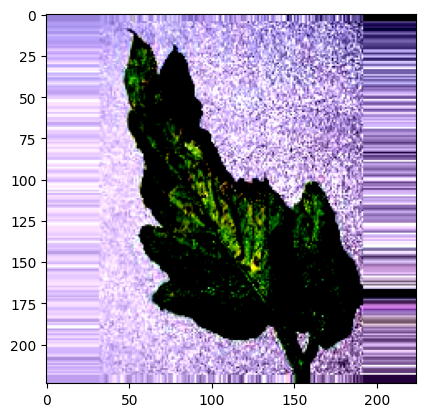

<Figure size 500x500 with 0 Axes>

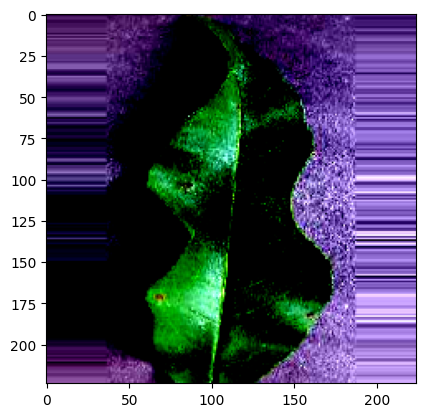

<Figure size 500x500 with 0 Axes>

In [ ]:
t_img, label = next(train)

def plotImage(img_arr, label):
    for im, l in zip(img_arr, label):
        plt.imshow(im)
        plt.figure(figsize=(5, 5))
        plt.show()

plotImage(t_img[:3], label[:3])

In [ ]:
# Building the model
from keras.layers import Dense, Flatten
from keras.models import Model

base_model = DenseNet201(weights='imagenet', input_shape=(224, 224, 3), include_top=False)

for layer in base_model.layers:
    layer.trainable = False

X = Flatten()(base_model.output)
X = Dense(units=38, activation='softmax')(X)


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Creating the model
model = Model(base_model.input, X)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

# Early stopping
es = EarlyStopping(monitor='val_accuracy', min_delta=0.01, patience=3, verbose=1)

# Model checkpoint
mc = ModelCheckpoint(filepath="best_model(DenseNet201).keras", monitor='val_accuracy', verbose=1, save_best_only=True)

cb = [es, mc]

In [ ]:
his = model.fit(train,
                steps_per_epoch=128,
                epochs=50,
                verbose=1,
                callbacks=cb,
                validation_data=val,
                validation_steps=128)

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7603 - loss: 1.8015
Epoch 1: val_accuracy improved from -inf to 0.89752, saving model to best_model(DenseNet201).keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 349s 3s/step - accuracy: 0.7608 - loss: 1.7971 - val_accuracy: 0.8975 - val_loss: 0.7045
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8774 - loss: 0.8694
Epoch 2: val_accuracy improved from 0.89752 to 0.93350, saving model to best_model(DenseNet201).keras


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


128/128 ━━━━━━━━━━━━━━━━━━━━ 239s 2s/step - accuracy: 0.8774 - loss: 0.8694 - val_accuracy: 0.9335 - val_loss: 0.5180
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9039 - loss: 0.7265
Epoch 3: val_accuracy did not improve from 0.93350
128/128 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.9040 - loss: 0.7266 - val_accuracy: 0.9268 - val_loss: 0.5533
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8996 - loss: 0.9046
Epoch 4: val_accuracy improved from 0.93350 to 0.96549, saving model to best_model(DenseNet201).keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.8996 - loss: 0.9042 - val_accuracy: 0.9655 - val_loss: 0.2623
Epoch 5/50
 38/128 ━━━━━━━━━━━━━━━━━━━━ 2:10 1s/step - accuracy: 0.9161 - loss: 0.7516
Epoch 5: val_accuracy did not improve from 0.96549
128/128 ━━━━━━━━━━━━━━━━━━━━ 117s 914ms/step - accuracy: 0.9171 - loss: 0.7356 - val_accuracy: 0.9277 - val_loss: 0.7948
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0

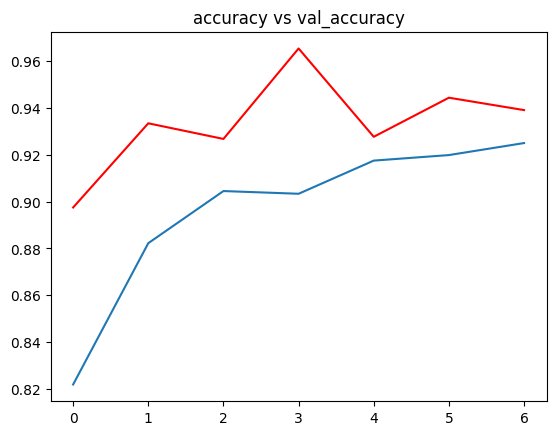

In [ ]:
# Plotting accuracy and loss
h = his.history
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'], c='red')
plt.title('accuracy vs val_accuracy')
plt.show()


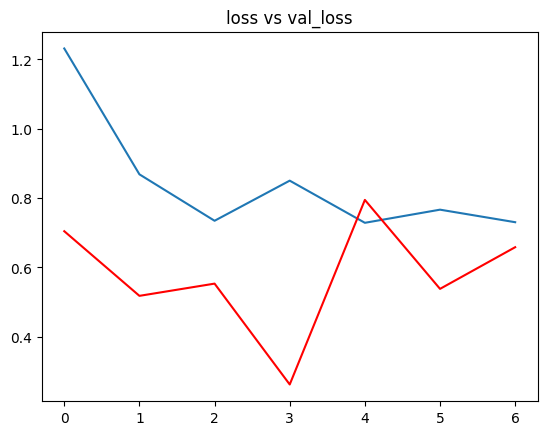

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'], c='red')
plt.title('loss vs val_loss')
plt.show()

In [ ]:
# Load best model
from keras.models import load_model

model = load_model('/content/best_model(DenseNet201).keras')

In [ ]:
# Display accuracy of the model
acc = model.evaluate(val)[1]
print(f"The accuracy of the model = {acc*100} %")

138/138 ━━━━━━━━━━━━━━━━━━━━ 89s 523ms/step - accuracy: 0.9491 - loss: 0.4237
The accuracy of the model = 94.92374062538147 %


In [ ]:
# Creating dictionaries of Classes
ref = dict(zip(list(train.class_indices.values()), list(train.class_indices.keys())))
for i in ref:
    print(ref[i])

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy


In [ ]:
# Prediction function
def prediction(path):
    img = load_img(path, target_size=(224, 224))
    i = img_to_array(img)
    im = preprocess_input(i)
    img = np.expand_dims(im, axis=0)
    pred = np.argmax(model.predict(img))
    print(f'The image belongs to {ref[pred]}')

# Testing with a sample image
path = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Grape___Black_rot/004175d8-dc74-4285-8401-3cc9565730bb___FAM_B.Rot 0626.JPG'
prediction(path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
The image belongs to Grape___Black_rot
